# Exploratory Data Analysis - Pipeline Accidents

Follow-up EDA on top of the original notebook. Here I'm digging a bit deeper into
missing data, distributions, time trends and how the numeric severity columns
(release volumes, costs, injuries) relate to each other before doing any
modeling.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set(style="whitegrid")
plt.style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
pipe = pd.read_csv('pipeline-accidents.csv')
pipe.shape

(2795, 48)

In [3]:
pipe.head()

,Report Number,Supplemental Number,Accident Year,Accident Date/Time,Operator ID,Operator Name,Pipeline/Facility Name,Pipeline Location,Pipeline Type,Liquid Type,Liquid Subtype,Liquid Name,Accident City,Accident County,Accident State,Accident Latitude,Accident Longitude,Cause Category,Cause Subcategory,Unintentional Release (Barrels),Intentional Release (Barrels),Liquid Recovery (Barrels),Net Loss (Barrels),Liquid Ignition,Liquid Explosion,Pipeline Shutdown,Shutdown Date/Time,Restart Date/Time,Public Evacuations,Operator Employee Injuries,Operator Contractor Injuries,Emergency Responder Injuries,Other Injuries,Public Injuries,All Injuries,Operator Employee Fatalities,Operator Contractor Fatalities,Emergency Responder Fatalities,Other Fatalities,Public Fatalities,All Fatalities,Property Damage Costs,Lost Commodity Costs,Public/Private Property Damage Costs,Emergency Response Costs,Environmental Remediation Costs,Other Costs,All Costs
0,20100016,17305,2010,1/1/2010 7:15 AM,32109,ONEOK NGL PIPELINE LP,KINDER MORGAN JCT,ONSHORE,ABOVEGROUND,"HVL OR OTHER FLAMMABLE OR TOXIC FLUID, GAS",LPG (LIQUEFIED PETROLEUM GAS) / NGL (NATURAL G...,NaN,MCPHERSON,MCPHERSON,KS,38.67070,-97.78123,INCORRECT OPERATION,PIPELINE/EQUIPMENT OVERPRESSURED,21.00,0.1,0.00,21.0,NO,NO,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110.0,1517.0,0.0,0.0,0.0,0.0,1627
1,20100254,17331,2010,1/4/2010 8:30 AM,15786,PORTLAND PIPELINE CORP,24-INCH MAIN LINE,ONSHORE,ABOVEGROUND,CRUDE OIL,NaN,NaN,RAYMOND,CUMBERLAND,ME,43.94028,-70.49336,MATERIAL/WELD/EQUIP FAILURE,PUMP OR PUMP-RELATED EQUIPMENT,0.12,0.0,0.12,0.0,NO,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4000.0,8.0,0.0,0.0,0.0,0.0,4008
2,20100038,17747,2010,1/5/2010 10:30 AM,20160,"PETROLOGISTICS OLEFINS, LLC",NaN,ONSHORE,ABOVEGROUND,"HVL OR OTHER FLAMMABLE OR TOXIC FLUID, GAS",OTHER HVL,ETHANE,SULPHER,CALCASIEU,LA,30.18240,-93.35240,MATERIAL/WELD/EQUIP FAILURE,DEFECTIVE OR LOOSE TUBING/FITTING,2.00,0.0,0.00,2.0,NO,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,200.0,0.0,0.0,0.0,0.0,200
3,20100260,18574,2010,1/6/2010 7:30 PM,11169,"ENBRIDGE ENERGY, LIMITED PARTNERSHIP",SUPERIOR TERMINAL,ONSHORE,UNDERGROUND,CRUDE OIL,NaN,NaN,SUPERIOR,DOUGLAS,WI,46.68930,-92.06120,NATURAL FORCE DAMAGE,TEMPERATURE,0.48,0.0,0.48,0.0,NO,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.0,40.0,0.0,11300.0,0.0,0.0,11540
4,20100030,16276,2010,1/7/2010 1:00 PM,300,"PLAINS PIPELINE, L.P.",RED RIVER EAST,ONSHORE,UNDERGROUND,CRUDE OIL,NaN,NaN,SHERMAN,GRAYSON,TX,33.58266,-96.64881,EXCAVATION DAMAGE,THIRD PARTY EXCAVATION DAMAGE,700.00,NaN,698.00,2.0,NO,NO,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20000.0,150.0,0.0,7500.0,2000.0,0.0,29650


## Missing data

Which columns actually have gaps, and how bad are they.

In [4]:
missing = pipe.isnull().sum()
missing = missing[missing > 0].sort_values(ascending = False)
missing

Public Fatalities                       2787
All Fatalities                          2787
Operator Employee Fatalities            2787
Operator Contractor Fatalities          2787
Emergency Responder Fatalities          2787
Other Fatalities                        2787
Public Injuries                         2783
All Injuries                            2783
Operator Contractor Injuries            2783
Operator Employee Injuries              2783
Other Injuries                          2783
Emergency Responder Injuries            2783
Liquid Name                             2573
Intentional Release (Barrels)           1586
Restart Date/Time                       1454
Liquid Subtype                          1446
Shutdown Date/Time                      1405
Public Evacuations                       457
Accident City                            315
Pipeline Shutdown                        212
Pipeline/Facility Name                   121
Accident County                           75
Pipeline T

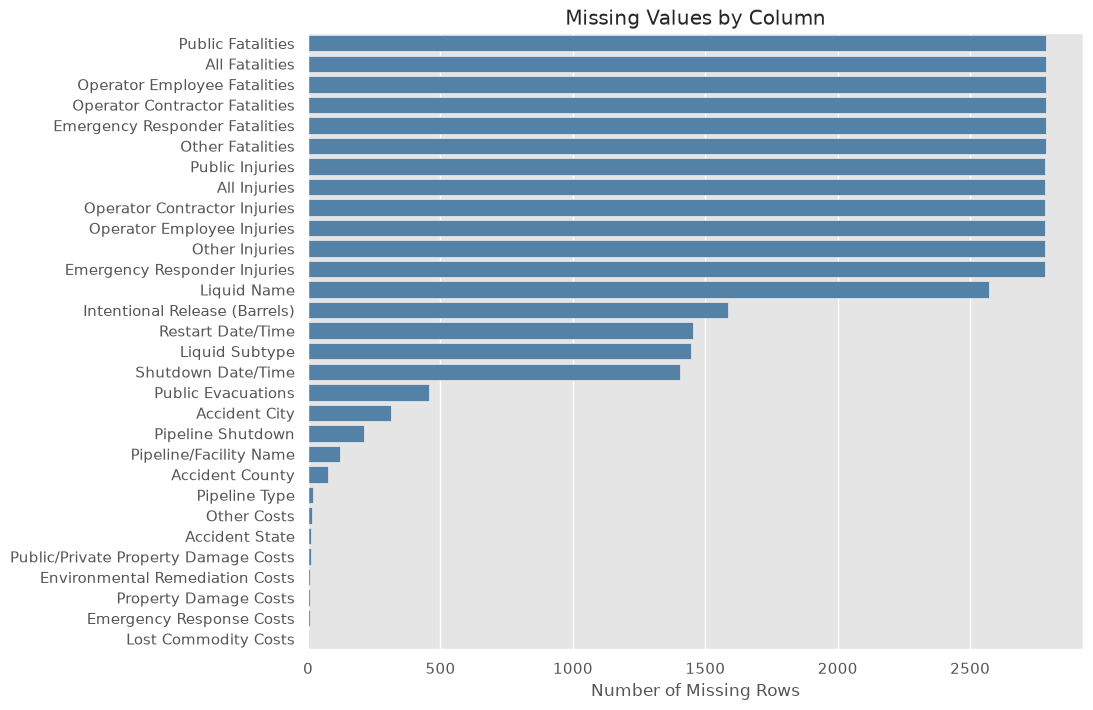

In [5]:
plt.figure(figsize = (10, 8))
sns.barplot(x = missing.values, y = missing.index, color = 'steelblue')
plt.title('Missing Values by Column')
plt.xlabel('Number of Missing Rows')
plt.ylabel('')
plt.show()

Most of the fatality/injury columns are missing for the vast majority of rows -
that just means no one was hurt, so `NaN` here really means 0, not "unknown".
Same story for `Intentional Release (Barrels)` and the shutdown/restart
timestamps - missing usually means "didn't happen", not bad data collection.

## Accidents over time

In [6]:
year_counts = pipe['Accident Year'].value_counts().sort_index()
year_counts

Accident Year
2010    350
2011    345
2012    366
2013    401
2014    454
2015    462
2016    415
2017      2
Name: count, dtype: int64

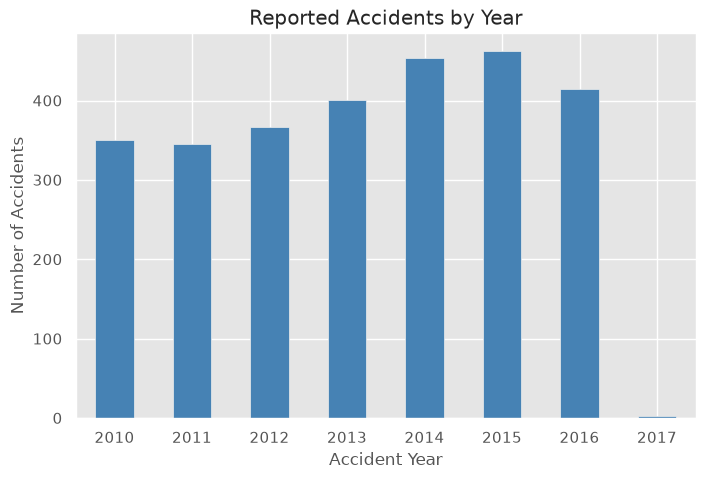

In [7]:
plt.figure(figsize = (8, 5))
year_counts.plot(kind = 'bar', color = 'steelblue')
plt.title('Reported Accidents by Year')
plt.xlabel('Accident Year')
plt.ylabel('Number of Accidents')
plt.xticks(rotation = 0)
plt.show()

## Pipeline type and liquid type

In [8]:
pipe['Pipeline Type'].value_counts()

Pipeline Type
ABOVEGROUND        1475
UNDERGROUND         985
TANK                301
TRANSITION AREA      16
Name: count, dtype: int64

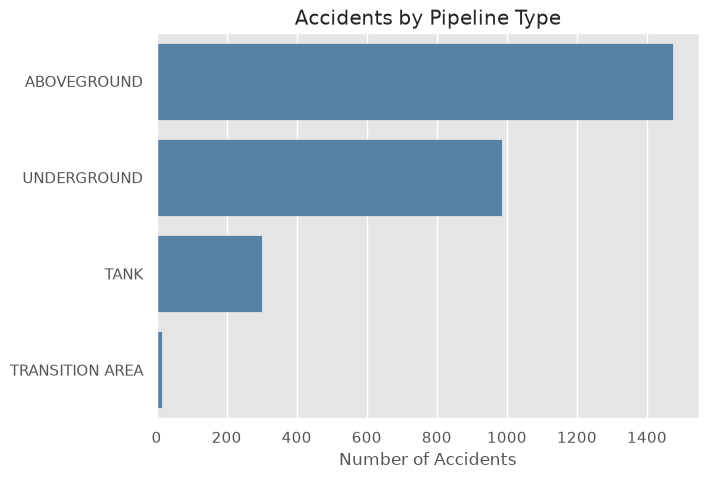

In [9]:
plt.figure(figsize = (7, 5))
sns.countplot(y = 'Pipeline Type', data = pipe, order = pipe['Pipeline Type'].value_counts().index, color = 'steelblue')
plt.title('Accidents by Pipeline Type')
plt.xlabel('Number of Accidents')
plt.ylabel('')
plt.show()

In [10]:
pipe['Liquid Type'].value_counts()

Liquid Type
CRUDE OIL                                               1398
REFINED AND/OR PETROLEUM PRODUCT (NON-HVL), LIQUID       939
HVL OR OTHER FLAMMABLE OR TOXIC FLUID, GAS               418
CO2 (CARBON DIOXIDE)                                      38
BIOFUEL / ALTERNATIVE FUEL(INCLUDING ETHANOL BLENDS)       2
Name: count, dtype: int64

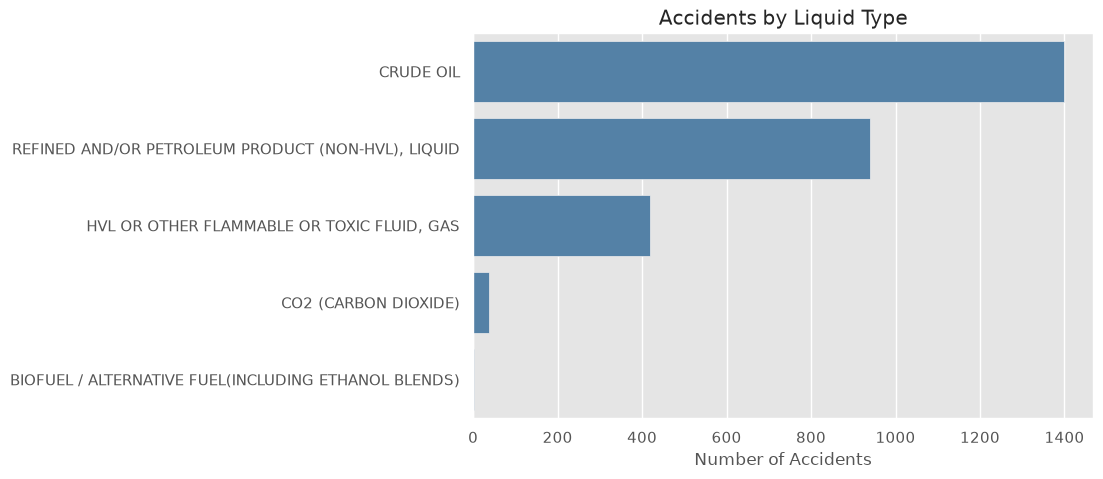

In [11]:
plt.figure(figsize = (8, 5))
sns.countplot(y = 'Liquid Type', data = pipe, order = pipe['Liquid Type'].value_counts().index, color = 'steelblue')
plt.title('Accidents by Liquid Type')
plt.xlabel('Number of Accidents')
plt.ylabel('')
plt.show()

Crude oil pipelines account for about half the reported accidents, which makes sense given how much of the network carries crude.

## Where the accidents happen

In [12]:
top_states = pipe['Accident State'].value_counts().head(15)
top_states

Accident State
TX    1004
OK     236
LA     169
CA     153
KS     150
IL     108
WY      98
NJ      85
MN      59
IN      57
NM      57
OH      53
ND      49
IA      46
PA      45
Name: count, dtype: int64

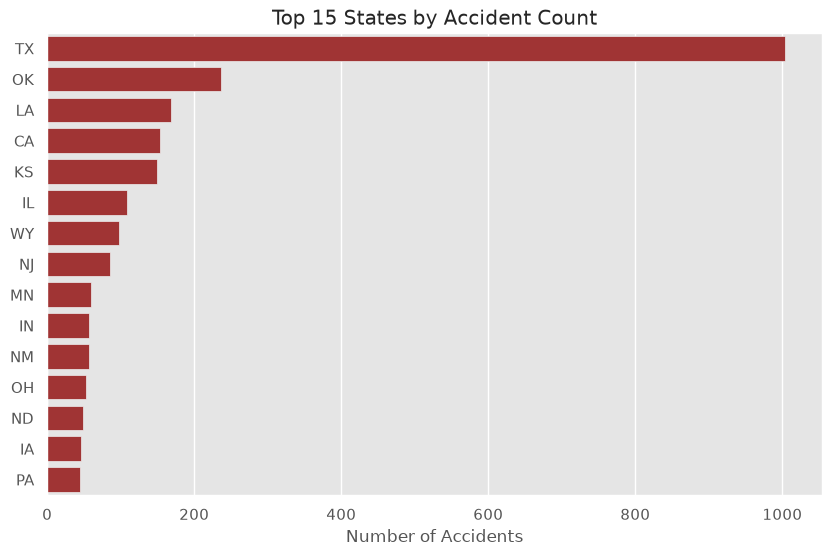

In [13]:
plt.figure(figsize = (10, 6))
sns.barplot(x = top_states.values, y = top_states.index, color = 'firebrick')
plt.title('Top 15 States by Accident Count')
plt.xlabel('Number of Accidents')
plt.ylabel('')
plt.show()

Texas is way out in front, which tracks with it having the largest pipeline mileage in the country.

## Cause category breakdown

In [14]:
cause_counts = pipe['Cause Category'].value_counts()
cause_counts

Cause Category
MATERIAL/WELD/EQUIP FAILURE    1435
CORROSION                       592
INCORRECT OPERATION             378
NATURAL FORCE DAMAGE            118
ALL OTHER CAUSES                118
EXCAVATION DAMAGE                97
OTHER OUTSIDE FORCE DAMAGE       57
Name: count, dtype: int64

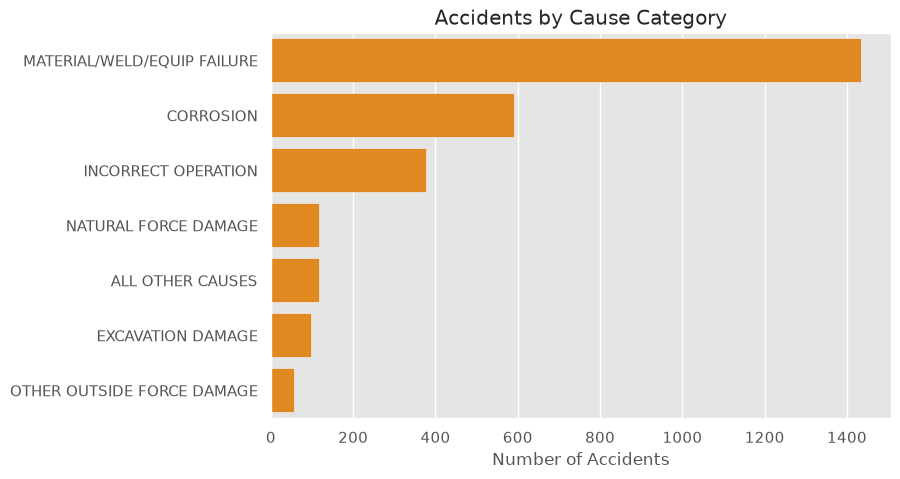

In [15]:
plt.figure(figsize = (8, 5))
sns.barplot(x = cause_counts.values, y = cause_counts.index, color = 'darkorange')
plt.title('Accidents by Cause Category')
plt.xlabel('Number of Accidents')
plt.ylabel('')
plt.show()

## Severity: release volumes and cost

These columns are heavily right skewed - a handful of large incidents drag the mean way above the median - so I'm looking at them on a log scale.

In [16]:
pipe[['Unintentional Release (Barrels)', 'Net Loss (Barrels)', 'All Costs']].describe()

,Unintentional Release (Barrels),Net Loss (Barrels),All Costs
count,2795.000000,2795.000000,2.795000e+03
mean,207.245843,132.194050,8.340332e+05
std,1368.667813,1185.019252,1.657830e+07
min,0.000000,0.000000,0.000000e+00
25%,0.480000,0.000000,5.039500e+03
50%,2.000000,0.000000,2.312900e+04
75%,20.000000,2.000000,1.172325e+05
max,30565.000000,30565.000000,8.405261e+08


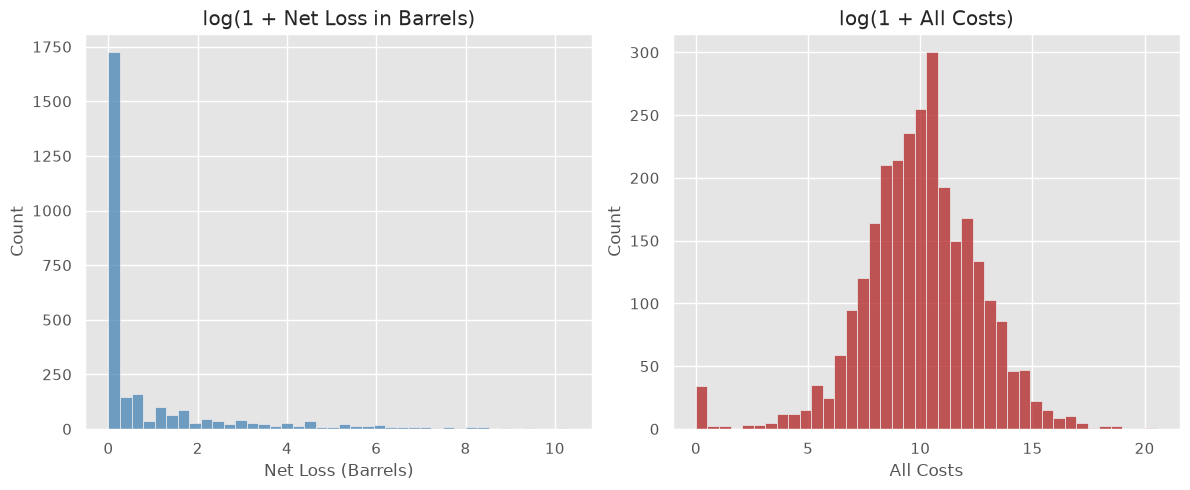

In [17]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

sns.histplot(np.log1p(pipe['Net Loss (Barrels)']), bins = 40, color = 'steelblue', ax = axes[0])
axes[0].set_title('log(1 + Net Loss in Barrels)')

sns.histplot(np.log1p(pipe['All Costs']), bins = 40, color = 'firebrick', ax = axes[1])
axes[1].set_title('log(1 + All Costs)')

plt.tight_layout()
plt.show()

## Total cost and net loss by year

In [18]:
yearly = pipe.groupby('Accident Year')[['Net Loss (Barrels)', 'All Costs']].sum()
yearly

,Net Loss (Barrels),All Costs
Accident Year,,
2010,49451.71,1075193990
2011,57374.85,273526547
2012,29247.26,145247426
2013,85597.80,278525540
2014,21686.46,131684524
2015,81954.61,253696042
2016,44169.68,173161626
2017,0.00,87228


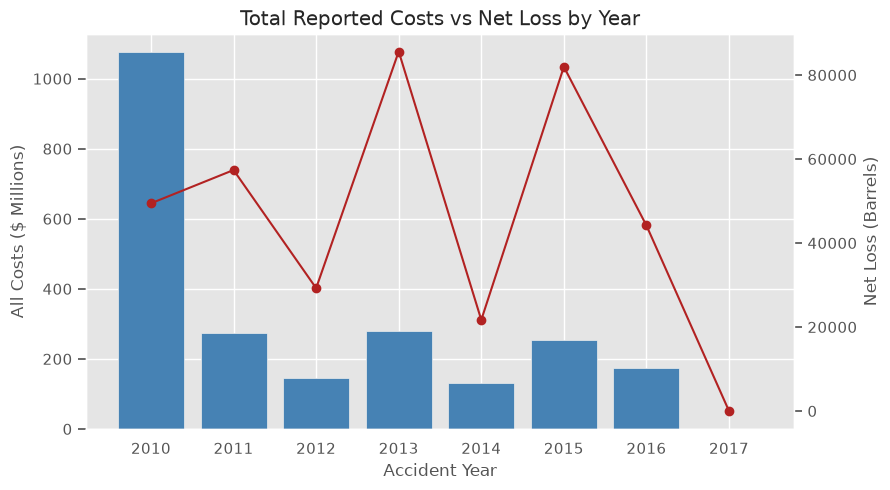

In [19]:
fig, ax1 = plt.subplots(figsize = (9, 5))

ax1.bar(yearly.index, yearly['All Costs'] / 1e6, color = 'steelblue', label = 'All Costs ($M)')
ax1.set_ylabel('All Costs ($ Millions)')
ax1.set_xlabel('Accident Year')

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['Net Loss (Barrels)'], color = 'firebrick', marker = 'o', label = 'Net Loss (Barrels)')
ax2.set_ylabel('Net Loss (Barrels)')
ax2.grid(False)

plt.title('Total Reported Costs vs Net Loss by Year')
fig.tight_layout()
plt.show()

Cost and volume don't move together year to year - 2010 has by far the highest total cost despite a below-average net loss, while 2013 has the highest net loss but a fairly ordinary total cost. A single very expensive (or very large) incident is enough to dominate a whole year's total, which is a good reminder that these yearly sums are driven by a handful of outliers rather than a steady trend.

## How do the severity columns relate to each other

In [20]:
severity_cols = ['Unintentional Release (Barrels)', 'Intentional Release (Barrels)',
                  'Liquid Recovery (Barrels)', 'Net Loss (Barrels)', 'Public Evacuations',
                  'All Injuries', 'All Fatalities', 'Property Damage Costs',
                  'Lost Commodity Costs', 'Emergency Response Costs',
                  'Environmental Remediation Costs', 'All Costs']

corr = pipe[severity_cols].fillna(0).corr()
corr

,Unintentional Release (Barrels),Intentional Release (Barrels),Liquid Recovery (Barrels),Net Loss (Barrels),Public Evacuations,All Injuries,All Fatalities,Property Damage Costs,Lost Commodity Costs,Emergency Response Costs,Environmental Remediation Costs,All Costs
Unintentional Release (Barrels),1.000000,0.005710,0.513211,0.918430,0.154174,0.048634,0.148645,0.139892,0.606975,0.293095,0.292777,0.318569
Intentional Release (Barrels),0.005710,1.000000,-0.007498,0.010051,0.030886,-0.003145,0.000081,0.004772,0.163891,-0.002908,-0.001674,-0.001317
Liquid Recovery (Barrels),0.513211,-0.007498,1.000000,0.131835,0.190953,0.001685,0.007633,0.113121,0.276139,0.557262,0.655912,0.663939
Net Loss (Barrels),0.918430,0.010051,0.131835,1.000000,0.090054,0.055394,0.168163,0.109433,0.573765,0.081669,0.035833,0.061923
Public Evacuations,0.154174,0.030886,0.190953,0.090054,1.000000,0.005362,0.012176,0.072119,0.125584,0.131039,0.086039,0.117569
All Injuries,0.048634,-0.003145,0.001685,0.055394,0.005362,1.000000,0.708487,0.002668,0.019580,-0.000358,-0.001028,-0.000812
All Fatalities,0.148645,0.000081,0.007633,0.168163,0.012176,0.708487,1.000000,0.033327,0.165556,0.006673,-0.000737,0.003558
Property Damage Costs,0.139892,0.004772,0.113121,0.109433,0.072119,0.002668,0.033327,1.000000,0.134596,0.208376,0.076251,0.178821
Lost Commodity Costs,0.606975,0.163891,0.276139,0.573765,0.125584,0.019580,0.165556,0.134596,1.000000,0.173225,0.057371,0.108292
Emergency Response Costs,0.293095,-0.002908,0.557262,0.081669,0.131039,-0.000358,0.006673,0.208376,0.173225,1.000000,0.751695,0.882844


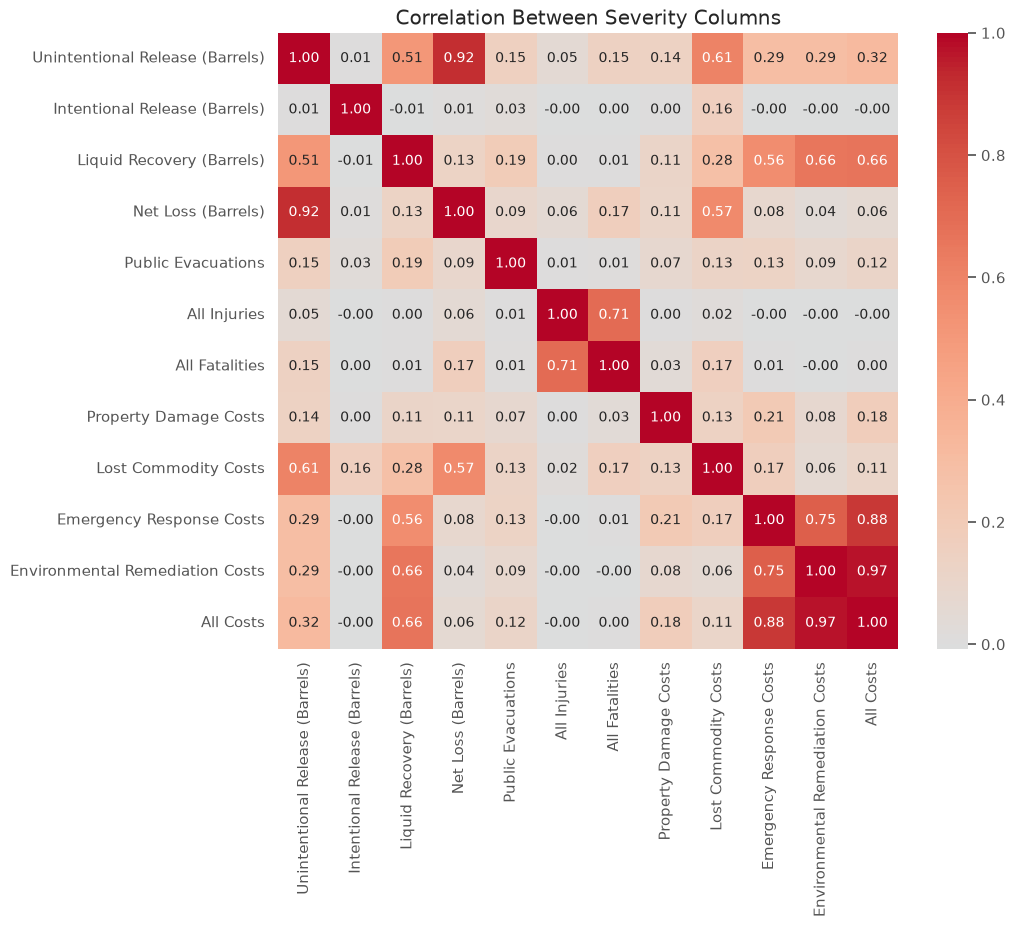

In [21]:
plt.figure(figsize = (10, 8))
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0)
plt.title('Correlation Between Severity Columns')
plt.show()

`Net Loss (Barrels)` and `Unintentional Release (Barrels)` are almost perfectly
correlated, which makes sense since net loss is basically the release minus
whatever liquid got recovered. `All Costs` correlates most with
`Environmental Remediation Costs` (0.97) and `Emergency Response Costs`
(0.88) - cleanup and emergency response are the two cost buckets that
basically decide the total, while `Property Damage Costs` barely moves with
it (0.18). Correlation here is just describing the data, not proving what's
driving what - I get into that properly (p-values, t-tests, and the
correlation-vs-causation caveat) in the next notebook.

## Cause category vs pipeline type

In [22]:
cause_pipe = pd.crosstab(pipe['Cause Category'], pipe['Pipeline Type'])
cause_pipe

Pipeline Type,ABOVEGROUND,TANK,TRANSITION AREA,UNDERGROUND
Cause Category,,,,
ALL OTHER CAUSES,52,28,0,36
CORROSION,110,42,7,427
EXCAVATION DAMAGE,4,0,0,92
INCORRECT OPERATION,277,48,3,49
MATERIAL/WELD/EQUIP FAILURE,951,151,4,324
NATURAL FORCE DAMAGE,55,31,1,30
OTHER OUTSIDE FORCE DAMAGE,26,1,1,27


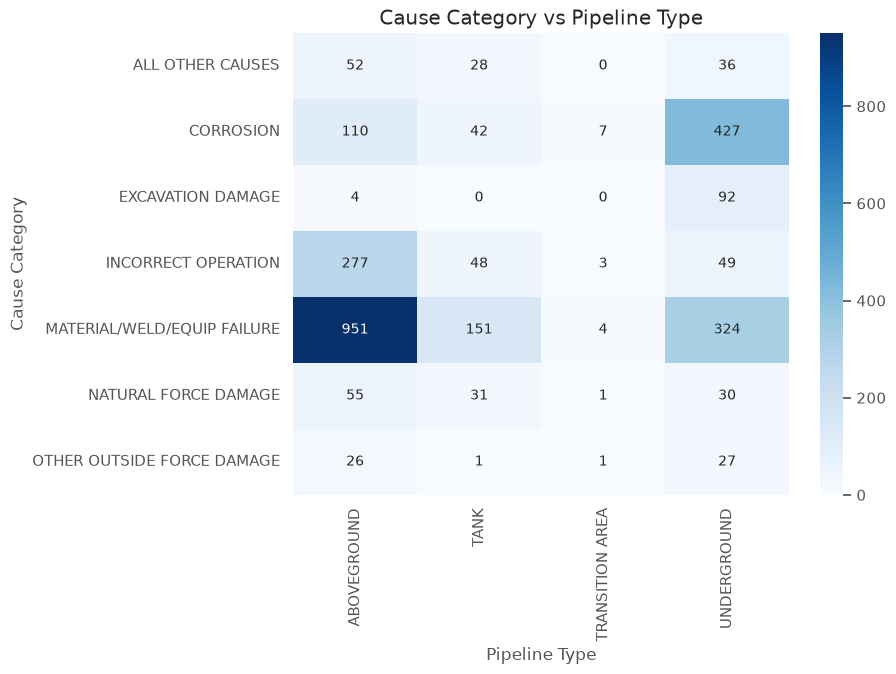

In [23]:
plt.figure(figsize = (8, 6))
sns.heatmap(cause_pipe, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Cause Category vs Pipeline Type')
plt.xlabel('Pipeline Type')
plt.ylabel('Cause Category')
plt.show()

Corrosion shows up a lot more on underground pipelines than aboveground ones - which lines up with underground pipe being harder to inspect visually.